# Integrantes del grupo : Grupo 6
- Monzón Gallegos, Alessandro Facundo
- Ramírez Chuquimarca, Mateo Elías
- Vargas Zeballos, Arantza

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

#Creamos el dataset

In [ ]:
data = {
    "Area": [95,123,118,96,182,86,63,193,155,128,195,115,105,140],
    "Habitaciones": [4,2,2,4,4,4,2,2,2,2,5,5,3,3],
    "Antiguedad": [13,14,22,8,19,5,7,3,29,3,18,22,10,6],
    "Distancia": [12.5,8.0,15.0,5.5,9.0,3.5,18.0,4.0,22.0,6.5,7.5,20.0,2.0,14.0],
    "Precio": [171600,216200,196900,190200,305700,180100,133600,320000,
               242700,216800,357400,219800,198500,241300]
}

df = pd.DataFrame(data)

print(df)

    Area  Habitaciones  Antiguedad  Distancia  Precio
0     95             4          13       12.5  171600
1    123             2          14        8.0  216200
2    118             2          22       15.0  196900
3     96             4           8        5.5  190200
4    182             4          19        9.0  305700
5     86             4           5        3.5  180100
6     63             2           7       18.0  133600
7    193             2           3        4.0  320000
8    155             2          29       22.0  242700
9    128             2           3        6.5  216800
10   195             5          18        7.5  357400
11   115             5          22       20.0  219800
12   105             3          10        2.0  198500
13   140             3           6       14.0  241300


# Vemos la dispersión y correlación de nuestro dataset

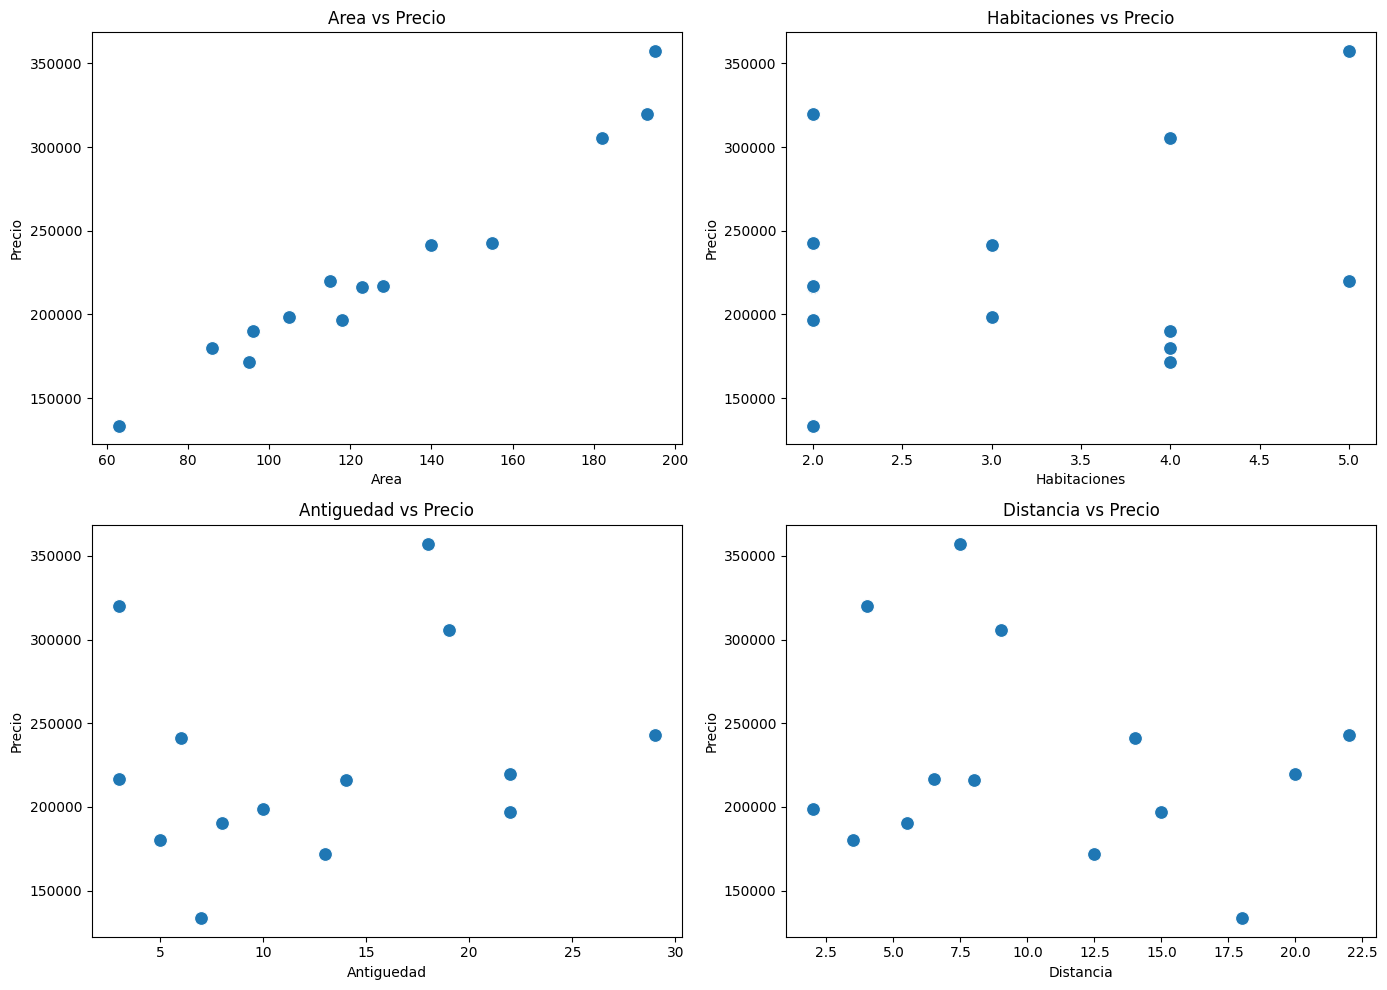

In [ ]:
features = ["Area", "Habitaciones", "Antiguedad", "Distancia"]

plt.figure(figsize=(14,10))

for i, col in enumerate(features):

    plt.subplot(2,2,i+1)

    sns.scatterplot(
        data=df,
        x=col,
        y="Precio",
        s=100
    )

    plt.title(f"{col} vs Precio")

plt.tight_layout()
plt.show()

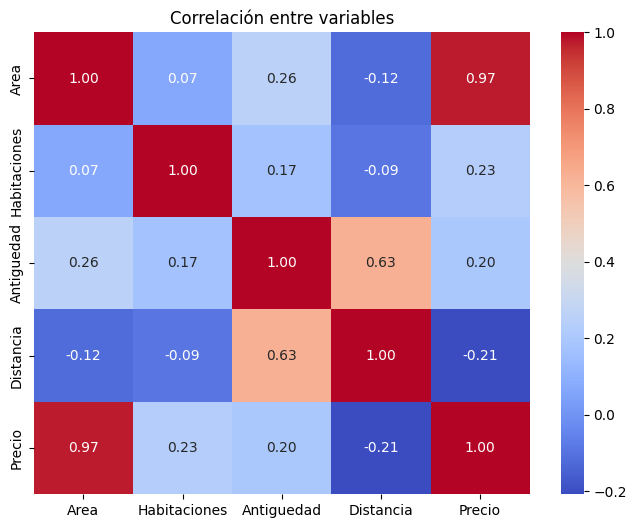

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlación entre variables")
plt.show()

El análisis muestra que el Área presenta la relación más fuerte con el Precio, lo cual explica su alta importancia en los modelos de regresión lineal y posteriormente de la logística.

La Distancia al centro urbano también presenta una correlación negativa significativa, consistente con la lógica económica del mercado inmobiliario.

Por otro lado, variables como el número de habitaciones y la antigüedad muestran relaciones más débiles o con mayor dispersión, lo que sugiere que su aporte al modelo es complementario más que determinante.

# Construimos la matriz de caracteristicas X y el vector de columna de precios Y

In [ ]:
X = df[["Area", "Habitaciones", "Antiguedad", "Distancia"]].values

y = df["Precio"].values.reshape(-1,1)

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (14, 4)
Dimensión de y: (14, 1)


In [ ]:
print("\nRangos de las variables:\n")

for columna in ["Area", "Habitaciones", "Antiguedad", "Distancia"]:
    print(f"{columna}:")
    print("Min =", df[columna].min())
    print("Max =", df[columna].max())
    print()

print("\nRango de la variable objetivo (Precio):\n")
print("Min =", df["Precio"].min())
print("Max =", df["Precio"].max())


Rangos de las variables:

Area:
Min = 63
Max = 195

Habitaciones:
Min = 2
Max = 5

Antiguedad:
Min = 3
Max = 29

Distancia:
Min = 2.0
Max = 22.0


Rango de la variable objetivo (Precio):

Min = 133600
Max = 357400


# Realizamos la normalización Z-Score a los features

In [ ]:
scaler = StandardScaler()

X_normalizado = scaler.fit_transform(X)

print("Datos normalizados:\n")
print(X_normalizado)

Datos normalizados:

[[-0.84716117  0.76200076  0.02730321  0.31709375]
 [-0.13145604 -1.01600102  0.15471817 -0.4093392 ]
 [-0.25926053 -1.01600102  1.17403788  0.72066761]
 [-0.82160027  0.76200076 -0.60977161 -0.81291307]
 [ 1.37663689  0.76200076  0.79179299 -0.24790966]
 [-1.07720924  0.76200076 -0.9920165  -1.13577216]
 [-1.66510988 -1.01600102 -0.73718658  1.20495625]
 [ 1.65780676 -1.01600102 -1.24684643 -1.05505739]
 [ 0.68649267 -1.01600102  2.06594263  1.85067443]
 [-0.00365156 -1.01600102 -1.24684643 -0.65148352]
 [ 1.70892856  1.65100165  0.66437803 -0.49005398]
 [-0.33594322  1.65100165  1.17403788  1.52781534]
 [-0.59155219 -0.12700013 -0.35494169 -1.37791648]
 [ 0.30307921 -0.12700013 -0.86460154  0.55923807]]


# Agregamos la columna de unos (bias)

In [ ]:
unos = np.ones((X_normalizado.shape[0],1))

X_b = np.hstack((unos, X_normalizado))

print("Dimensión final de X:", X_b.shape)

Dimensión final de X: (14, 5)


# Aplicamos la Ecuación Normal

In [ ]:
w_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("Pesos obtenidos con Ecuación Normal:\n")

for i, peso in enumerate(w_normal):
    print(f"w{i} = {peso[0]:.4f}")

Pesos obtenidos con Ecuación Normal:

w0 = 227914.2857
w1 = 57795.5478
w2 = 10267.2916
w3 = -3104.3643
w4 = -2496.4522


# Implementamos GD

In [ ]:
# Parámetros
learning_rate = 0.01
epochs = 5000

# Pesos 0 al comienzo
w_gd = np.zeros((X_b.shape[1],1))

# Numero de muestras
m = X_b.shape[0]

# Aqui guardamos los errores
mse_historial = []


for epoch in range(epochs):

    # Prediccion
    y_pred = X_b @ w_gd

    # Error
    error = y_pred - y

    # MSE
    mse = (1/m) * np.sum(error**2)

    mse_historial.append(mse)

    # Gradiente
    gradiente = (1/m) * (X_b.T @ error)

    # Actualizacion de pesos
    w_gd = w_gd - learning_rate * gradiente

    if epoch % 500 == 0:
        print(f"Epoch {epoch} -> MSE: {mse:.2f}")

Epoch 0 -> MSE: 55489455714.29
Epoch 500 -> MSE: 65456677.07
Epoch 1000 -> MSE: 54841242.13
Epoch 1500 -> MSE: 54116234.25
Epoch 2000 -> MSE: 54052822.97
Epoch 2500 -> MSE: 54047276.06
Epoch 3000 -> MSE: 54046790.84
Epoch 3500 -> MSE: 54046748.39
Epoch 4000 -> MSE: 54046744.68
Epoch 4500 -> MSE: 54046744.35


In [ ]:
print("\nPesos finales con Gradiente Descendiente:\n")

for i, peso in enumerate(w_gd):
    print(f"w{i} = {peso[0]:.4f}")


Pesos finales con Gradiente Descendiente:

w0 = 227914.2857
w1 = 57795.5148
w2 = 10267.2699
w3 = -3104.2927
w4 = -2496.5193


# Evolución del MSE

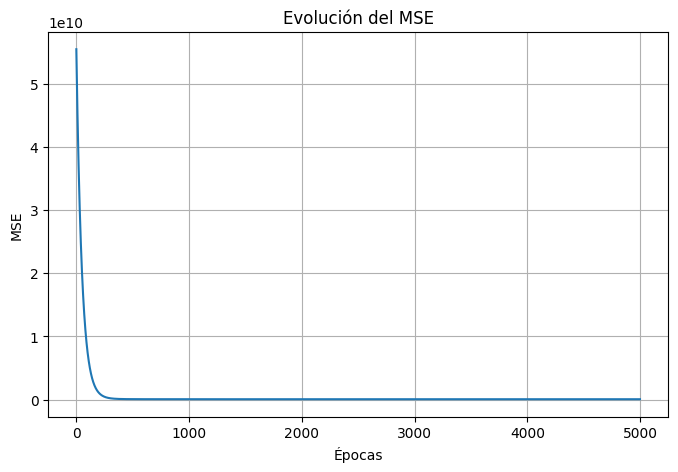

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(mse_historial)
plt.title("Evolución del MSE")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Interpretación Economica
Los resultados obtenidos presentan una interpretación económicamente coherente con el comportamiento esperado del mercado inmobiliario. En primer lugar, el área de la vivienda tiene una relación positiva con el precio, lo que indica que propiedades más grandes tienden a ser más costosas. Esto tiene sentido porque una mayor superficie habitable suele representar mayor comodidad, capacidad y valor comercial.

Asimismo, el número de habitaciones también influye positivamente en el precio de la propiedad. Una vivienda con más habitaciones generalmente resulta más atractiva para familias o compradores que buscan mayor funcionalidad y espacio interno, lo que incrementa su valor en el mercado.

Por otro lado, la antigüedad de la vivienda presenta una relación negativa con el precio. Esto refleja que las propiedades más antiguas suelen depreciarse con el tiempo debido al desgaste, posibles costos de mantenimiento y menor modernidad en comparación con viviendas más recientes.

De manera similar, la distancia al centro urbano también afecta negativamente el valor de la propiedad. Las viviendas ubicadas más lejos del centro suelen tener menor demanda debido a factores como tiempos de traslado mayores, menor acceso a servicios y menor cercanía a zonas comerciales o laborales.

En conjunto, los resultados muestran relaciones coherentes entre las variables y el precio de las viviendas, reflejando tendencias típicas del mercado inmobiliario. Además, el área parece ser el factor con mayor influencia dentro del modelo, lo cual es razonable dado que el tamaño de una propiedad suele ser uno de los principales determinantes de su valor.

# Predicción

In [ ]:
nueva_casa = np.array([[120,3,10,7]])

In [ ]:
nueva_casa_normalizada = scaler.transform(nueva_casa)

In [ ]:
nueva_casa_b = np.hstack((np.ones((1,1)), nueva_casa_normalizada))

In [ ]:
precio_predicho = nueva_casa_b @ w_gd

print("\nPrecio predicho para la nueva casa:")
print(f"${precio_predicho[0][0]:,.2f} USD")


Precio predicho para la nueva casa:
$217,107.63 USD


# Grafico real vs Predicho

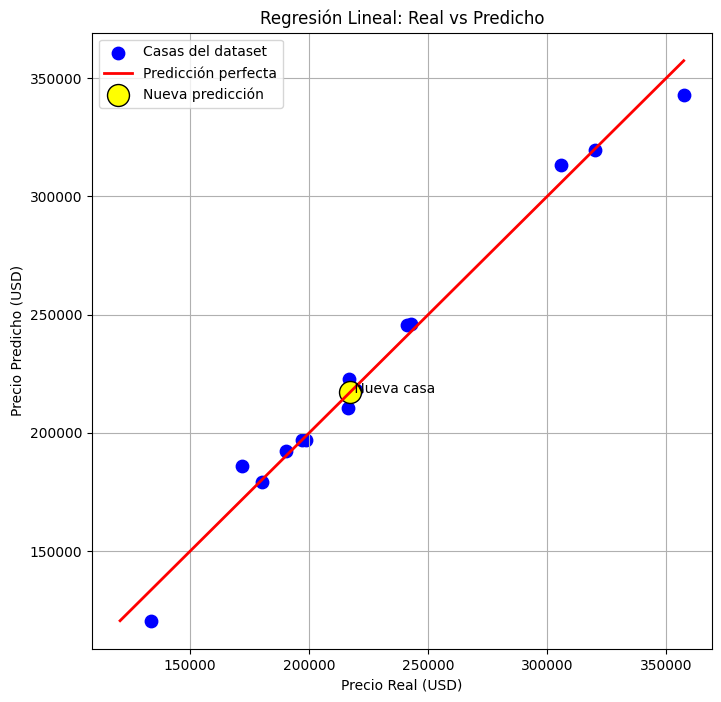

In [ ]:

y_pred_total = X_b @ w_gd


plt.figure(figsize=(8,8))

plt.scatter(y,
            y_pred_total,
            color='blue',
            s=80,
            label='Casas del dataset')


valor_min = min(y.min(), y_pred_total.min())
valor_max = max(y.max(), y_pred_total.max())

plt.plot([valor_min, valor_max],
         [valor_min, valor_max],
         color='red',
         linewidth=2,
         label='Predicción perfecta')

plt.scatter(precio_predicho,
            precio_predicho,
            color='yellow',
            edgecolors='black',
            s=250,
            label='Nueva predicción')

plt.text(precio_predicho[0][0],
         precio_predicho[0][0],
         ' Nueva casa',
         fontsize=10)

plt.xlabel("Precio Real (USD)")
plt.ylabel("Precio Predicho (USD)")

plt.title("Regresión Lineal: Real vs Predicho")

plt.legend()
plt.grid(True)

plt.show()

# Calculamos la calidad de nuestro modelo

In [ ]:
r2 = r2_score(y, y_pred_total)

print("R^2 =", r2)

R^2 = 0.9847520878395251


# Comparamos nuestro modelo con un modelo con normalización min-max y sin normalizar

In [ ]:
def entrenar_regresion_lineal(X, y, lr=0.01, epochs=5000):

    m = X.shape[0]
    w = np.zeros((X.shape[1],1))

    mse_historial = []

    for epoch in range(epochs):

        y_pred = X @ w
        error = y_pred - y

        mse = (1/m) * np.sum(error**2)


        if np.isnan(mse) or np.isinf(mse):
            print(f"Divergencia detectada en epoch {epoch}")
            print("El modelo explotó numéricamente (no converge).")
            break

        mse_historial.append(mse)

        gradiente = (1/m) * (X.T @ error)
        w = w - lr * gradiente

    return w, mse_historial

In [ ]:
def evaluar_regresion(y_true, y_pred, nombre="modelo"):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{nombre}")
    print("-"*30)
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2  : {r2:.4f}")

    return mse, rmse, r2

In [ ]:
X_raw = df[["Area","Habitaciones","Antiguedad","Distancia"]].values
y = df["Precio"].values.reshape(-1,1)

# SIN NORMALIZAR
X_no = np.hstack((np.ones((X_raw.shape[0],1)), X_raw))

# Z-SCORE
scaler_z = StandardScaler()
X_z = scaler_z.fit_transform(X_raw)
X_z = np.hstack((np.ones((X_z.shape[0],1)), X_z))

# MIN-MAX
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_raw)
X_mm = np.hstack((np.ones((X_mm.shape[0],1)), X_mm))

In [ ]:
w_no, loss_no = entrenar_regresion_lineal(X_no, y)
w_z, loss_z = entrenar_regresion_lineal(X_z, y)
w_mm, loss_mm = entrenar_regresion_lineal(X_mm, y)

Divergencia detectada en epoch 66
El modelo explotó numéricamente (no converge).


/tmp/ipykernel_668/304256016.py:13: RuntimeWarning: overflow encountered in square
  mse = (1/m) * np.sum(error**2)


In [ ]:
y_no = X_no @ w_no
y_z = X_z @ w_z
y_mm = X_mm @ w_mm

In [ ]:
evaluar_regresion(y, y_no, "SIN NORMALIZAR") # El modelo no convirgio
evaluar_regresion(y, y_z, "Z-SCORE")
evaluar_regresion(y, y_mm, "MIN-MAX")


SIN NORMALIZAR
------------------------------
MSE : inf
RMSE: inf
R²  : -inf

Z-SCORE
------------------------------
MSE : 54046744.33
RMSE: 7351.65
R²  : 0.9848

MIN-MAX
------------------------------
MSE : 58421722.20
RMSE: 7643.41
R²  : 0.9835


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)


(58421722.199618824, np.float64(7643.410377548678), 0.9835177992779494)

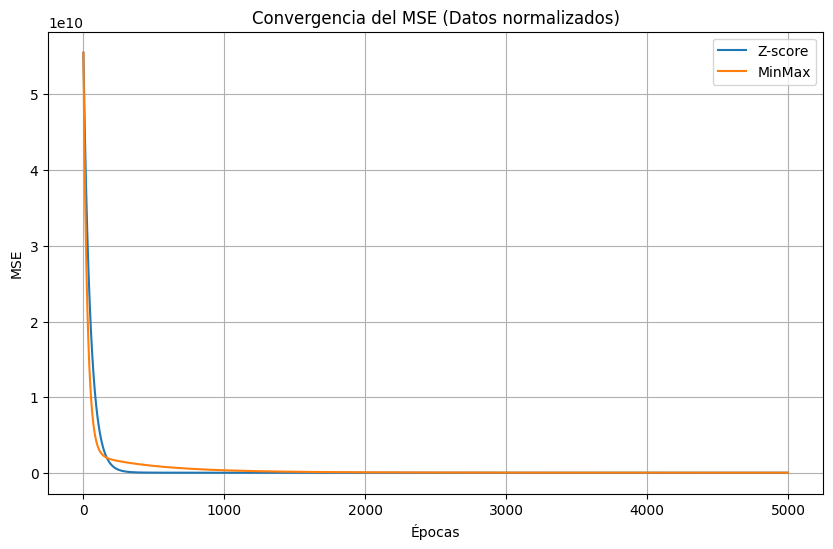

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(loss_z, label="Z-score")
plt.plot(loss_mm, label="MinMax")

plt.title("Convergencia del MSE (Datos normalizados)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

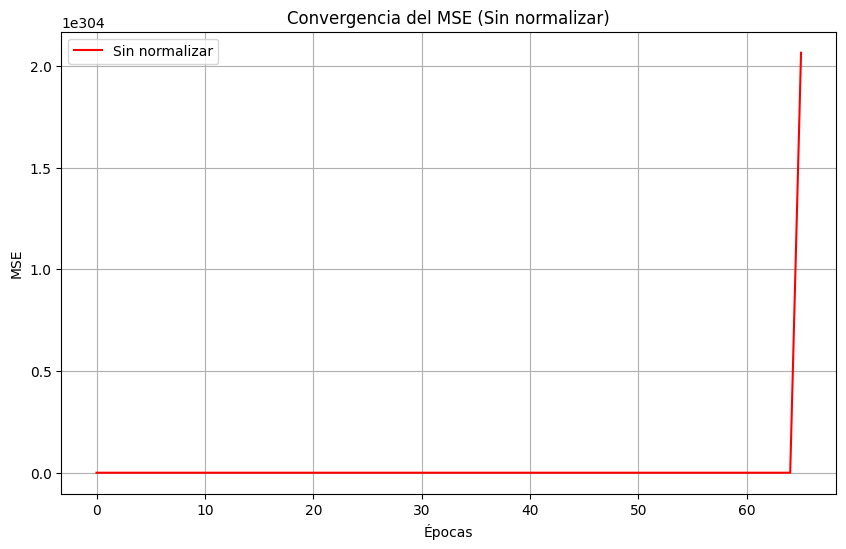

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(loss_no, label="Sin normalizar", color="red")

plt.title("Convergencia del MSE (Sin normalizar)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("\nCOMPARACIÓN R^2")
print("Sin normalizar:", r2_score(y, y_no))
print("Z-score:", r2_score(y, y_z))
print("MinMax:", r2_score(y, y_mm))


COMPARACIÓN R^2
Sin normalizar: -inf
Z-score: 0.9847520878395251
MinMax: 0.9835177992779494


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
